In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df= pd.read_csv("/content/loan_approval - loan_approval.csv")
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [3]:
df.columns

Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved'],
      dtype='object')

In [4]:
df.shape

(2000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


In [7]:
print(df.isnull().sum().sum())

0


In [9]:
df.describe(include="O")

,name,city
count,2000,2000
unique,2000,1882
top,Nicholas Cunningham,North Joseph
freq,1,4


[]

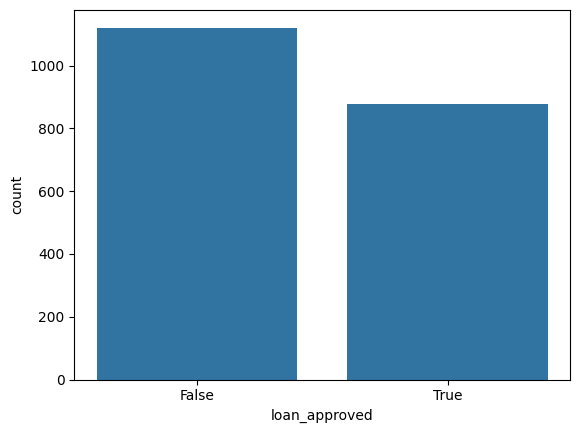

In [12]:
# a) Plot the distribution of the target variable.
target_var = 'loan_approved'
sns.countplot(x=target_var, data=df)
plt.plot()

[]

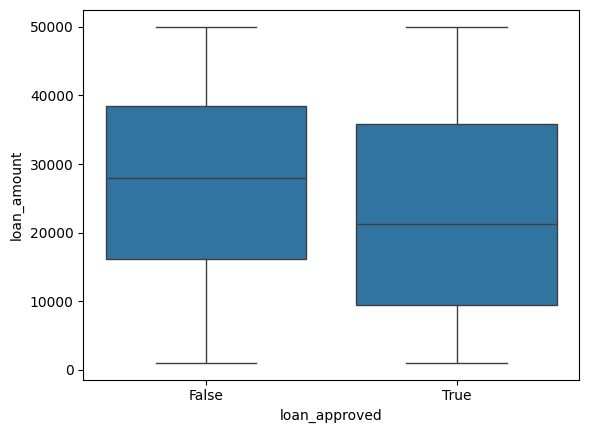

In [14]:
# b) Analyze the relationship between one numerical feature and the target variable.
sns.boxplot(x=target_var, y='loan_amount', data=df)
plt.plot()

[]

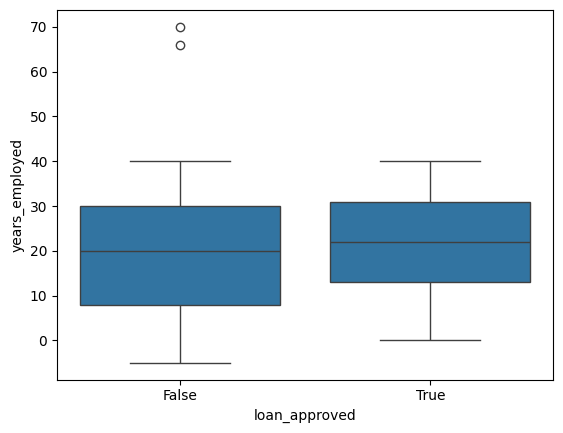

In [17]:
# c) Analyze the relationship between Years of Employment and the target variable.
sns.boxplot(x=target_var, y='years_employed',data=df)
plt.plot()

In [9]:
'''Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method'''
numerical_columns = df.select_dtypes(include=['number']).columns
for col in numerical_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
# b) Treat outliers using capping techniques
for col in numerical_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr

   # Capping (Winsorization) technique
  df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
  df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

In [33]:
#Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
#columns.
from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()
df[target_var]=lab.fit_transform(df[target_var])
df.head()


from sklearn.model_selection import train_test_split

X=df.drop(target_var, axis=1)
y = df[target_var]


In [29]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810.0,389.0,39698.0,27.0,50.0,0
1,Brandon Hall,New Jamesside,44592.0,729.0,15446.0,28.0,55.0,0
2,Rhonda Smith,Lake Roberto,33278.0,584.0,11189.0,13.0,45.0,0
3,Gabrielle Davis,West Melanieview,127196.0,344.0,48823.0,29.0,50.0,0
4,Valerie Gray,Mariastad,66048.0,496.0,47174.0,4.0,25.0,0


In [38]:
# Q6. b) Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 7)
(400, 7)
(1600,)
(400,)


In [40]:
# Q7. Apply feature scaling to the dataset using StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'Cynthia Palmer'

In [19]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)


NameError: name 'X_train_scaled' is not defined